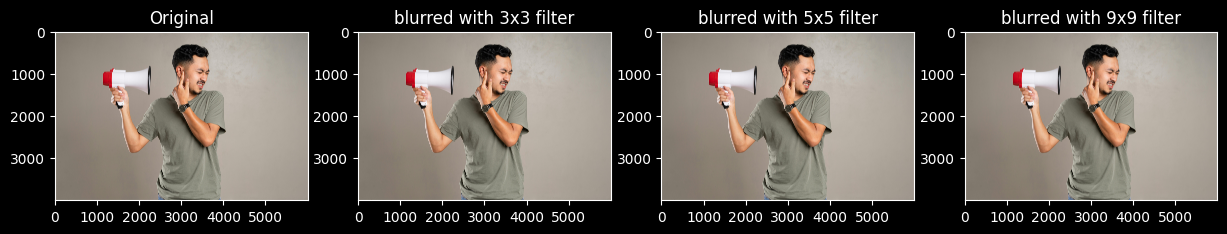

In [11]:
# Challenge 1
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('images/test_noise_image.jpg')

kernel_3x3 = np.ones((3, 3), np.float32) / 9
blurred_3x3 = cv2.filter2D(image, -1, kernel_3x3)

kernel_5x5 = np.ones((5, 5), np.float32) / 25
blurred_5x5 = cv2.filter2D(image, -1, kernel_5x5)

kernel_9x9 = np.ones((9, 9), np.float32) / 81
blurred_9x9 = cv2.filter2D(image, -1, kernel_9x9)

plt.figure(figsize=(15,7))
plt.subplot(141);plt.imshow(image[...,::-1]);plt.title("Original")
plt.subplot(142);plt.imshow(blurred_3x3[...,::-1]);plt.title("blurred with 3x3 filter")
plt.subplot(143);plt.imshow(blurred_5x5[...,::-1]);plt.title("blurred with 5x5 filter")
plt.subplot(144);plt.imshow(blurred_9x9[...,::-1]);plt.title("blurred with 9x9 filter")

plt.show();

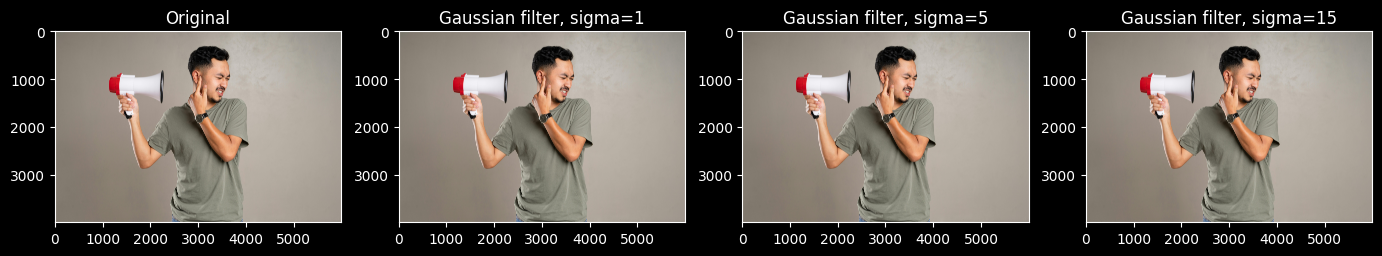

In [10]:
#Challenge 2
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('images/test_noise_image.jpg')

gaussian_1 = cv2.GaussianBlur(image, (5, 5), 1)
gaussian_5 = cv2.GaussianBlur(image, (5, 5), 5)
gaussian_15 = cv2.GaussianBlur(image, (5, 5), 15)

plt.figure(figsize=(17, 12))
plt.subplot(241);plt.imshow(image[...,::-1]);plt.title("Original")
plt.subplot(242);plt.imshow(gaussian_1[...,::-1]);plt.title("Gaussian filter, sigma=1")
plt.subplot(243);plt.imshow(gaussian_5[...,::-1]);plt.title("Gaussian filter, sigma=5")
plt.subplot(244);plt.imshow(gaussian_15[...,::-1]);plt.title("Gaussian filter, sigma=15")

plt.show();


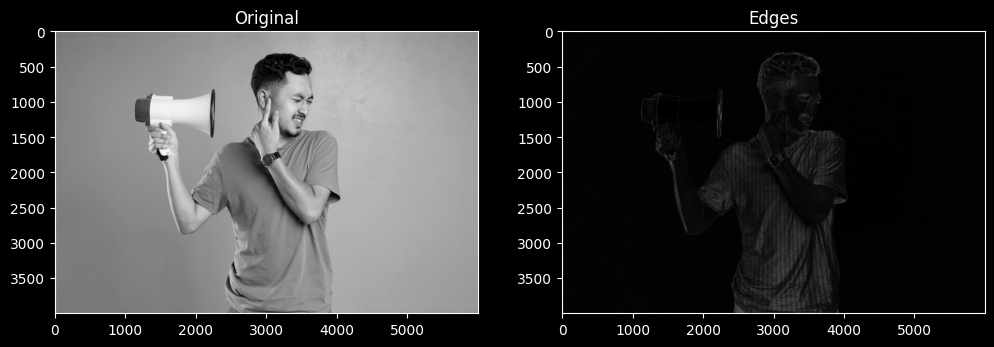

In [12]:
#Challenge 3
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('images/test_noise_image.jpg', cv2.IMREAD_GRAYSCALE)

kernel = np.array([[-1, -1, -1],
                   [-1, 8, -1],
                   [-1, -1, -1]])

edges = cv2.filter2D(image, -1, kernel)

plt.figure(figsize=(12,7))
plt.subplot(121); plt.imshow(image, cmap='gray'); plt.title("Original")
plt.subplot(122); plt.imshow(edges, cmap='gray'); plt.title("Edges")

plt.show()

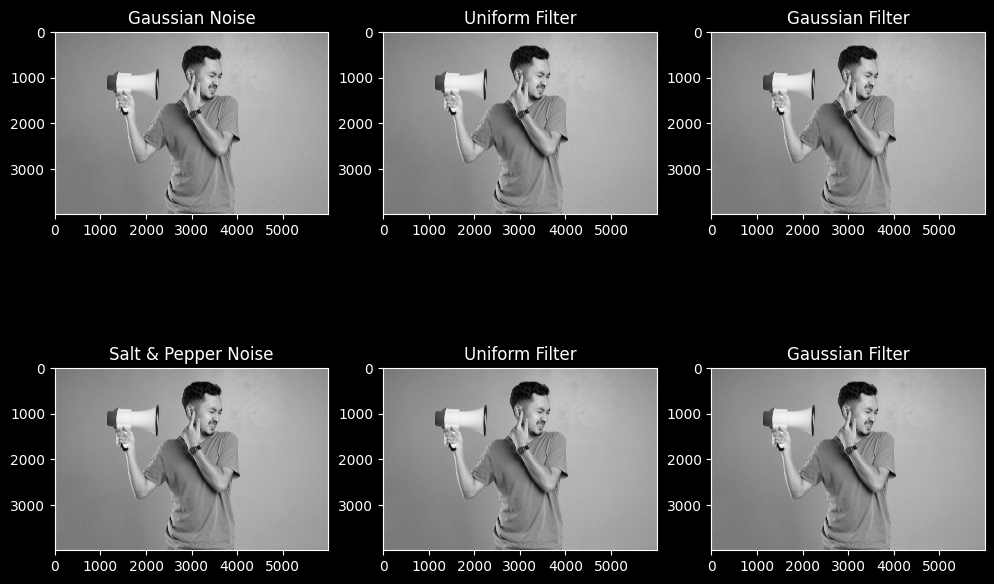

In [13]:
#Challenge 4
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('images/test_noise_image.jpg', cv2.IMREAD_GRAYSCALE)

gaussian_noise = image + np.random.normal(0, 25, image.shape)
gaussian_noise = np.clip(gaussian_noise, 0, 255).astype(np.uint8)

sp_noise = image.copy()
prob = 0.02
rand = np.random.rand(*image.shape)

sp_noise[rand < prob/2] = 0
sp_noise[rand > 1 - prob/2] = 255

uniform_gauss = cv2.blur(gaussian_noise, (5,5))
uniform_sp = cv2.blur(sp_noise, (5,5))

gauss_gauss = cv2.GaussianBlur(gaussian_noise, (5,5), 0)
gauss_sp = cv2.GaussianBlur(sp_noise, (5,5), 0)

plt.figure(figsize=(12,8))

plt.subplot(231); plt.imshow(gaussian_noise, cmap='gray'); plt.title("Gaussian Noise")
plt.subplot(232); plt.imshow(uniform_gauss, cmap='gray'); plt.title("Uniform Filter")
plt.subplot(233); plt.imshow(gauss_gauss, cmap='gray'); plt.title("Gaussian Filter")

plt.subplot(234); plt.imshow(sp_noise, cmap='gray'); plt.title("Salt & Pepper Noise")
plt.subplot(235); plt.imshow(uniform_sp, cmap='gray'); plt.title("Uniform Filter")
plt.subplot(236); plt.imshow(gauss_sp, cmap='gray'); plt.title("Gaussian Filter")

plt.show()

Original edge difference: 1
Box filter difference: 0
Gaussian filter difference: 1


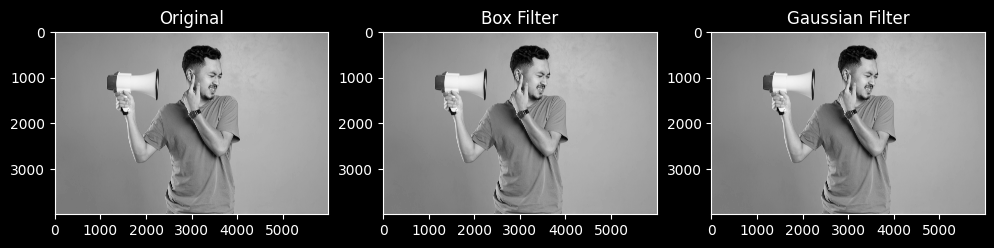

In [14]:
#Challenge 5
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('images/test_noise_image.jpg', cv2.IMREAD_GRAYSCALE)

box = cv2.blur(image, (5,5))

gauss = cv2.GaussianBlur(image, (5,5), 0)

row = image.shape[0] // 2

orig_diff = np.abs(int(image[row,120]) - int(image[row,121]))
box_diff = np.abs(int(box[row,120]) - int(box[row,121]))
gauss_diff = np.abs(int(gauss[row,120]) - int(gauss[row,121]))

print("Original edge difference:", orig_diff)
print("Box filter difference:", box_diff)
print("Gaussian filter difference:", gauss_diff)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(132)
plt.imshow(box, cmap='gray')
plt.title("Box Filter")

plt.subplot(133)
plt.imshow(gauss, cmap='gray')
plt.title("Gaussian Filter")

plt.show()

In [15]:
#Challenge 6
import cv2
import numpy as np
import time

image = cv2.imread('images/test_noise_image.jpg', cv2.IMREAD_GRAYSCALE)

kernel = np.ones((5,5), np.float32) / 25

runs = 20

start = time.time()
for i in range(runs):
    result1 = cv2.filter2D(image, -1, kernel)
end = time.time()
filter2d_time = (end - start) / runs

start = time.time()
for i in range(runs):
    result2 = cv2.GaussianBlur(image, (5,5), 0)
end = time.time()
gauss_time = (end - start) / runs

print("Average filter2D time:", filter2d_time)
print("Average GaussianBlur time:", gauss_time)

Average filter2D time: 0.0485556960105896
Average GaussianBlur time: 0.0025324344635009764


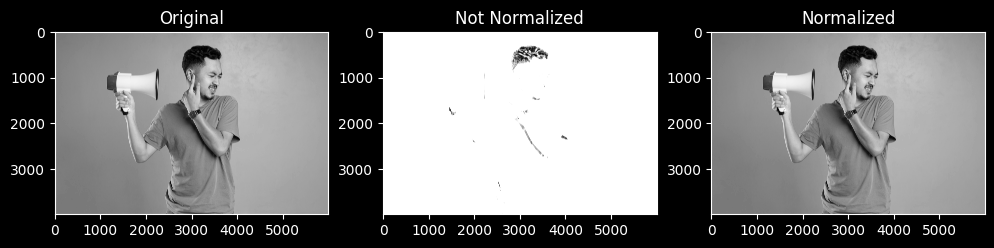

In [16]:
#Challenge 7
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('images/test_noise_image.jpg', cv2.IMREAD_GRAYSCALE)

kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

not_normalized = cv2.filter2D(image, -1, kernel)

kernel_norm = kernel / kernel.sum()
normalized = cv2.filter2D(image, -1, kernel_norm)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(132)
plt.imshow(not_normalized, cmap='gray')
plt.title("Not Normalized")

plt.subplot(133)
plt.imshow(normalized, cmap='gray')
plt.title("Normalized")

plt.show()

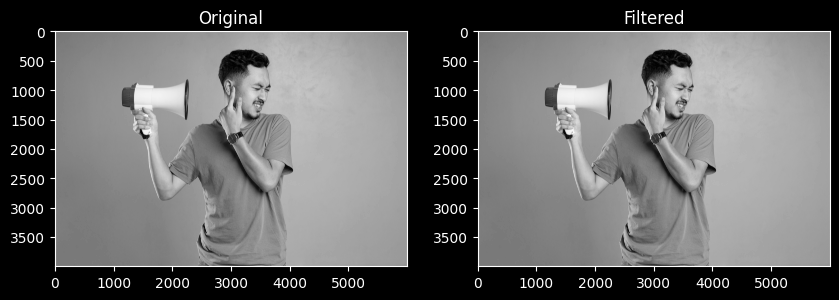

In [9]:
#  Final Challenge
import cv2
import matplotlib.pyplot as plt

def apply_filter(image, filter_type, ksize, sigma=0):

    if filter_type == "uniform":
        filtered = cv2.blur(image, (ksize, ksize))

    elif filter_type == "gaussian":
        filtered = cv2.GaussianBlur(image, (ksize, ksize), sigma)

    else:
        print("Invalid filter type")
        return image

    return filtered


image = cv2.imread('images/test_noise_image.jpg', cv2.IMREAD_GRAYSCALE)

choice = input("Choose filter (uniform / gaussian): ")

ksize = int(input("Enter kernel size (odd number): "))

sigma = 0
if choice == "gaussian":
    sigma = float(input("Enter sigma value: "))

result = apply_filter(image, choice, ksize, sigma)

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(result, cmap='gray')
plt.title("Filtered")

plt.show()